In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
df = pd.read_csv("Files/california_housing.csv")
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,4.0069,42.0,4.500000,1.000000,394.0,1.931373,34.27,-119.26,1.145178
1,2.4375,27.0,3.165060,1.139535,4165.0,2.362450,37.46,-122.14,1.061257
2,2.4205,43.0,4.433962,1.119497,464.0,2.918239,38.61,-121.46,0.475613
3,2.1903,52.0,4.276836,0.983051,767.0,2.166667,38.62,-122.87,0.955511
4,4.1856,19.0,6.095465,1.057279,1301.0,3.105012,36.08,-119.06,0.542906


In [3]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

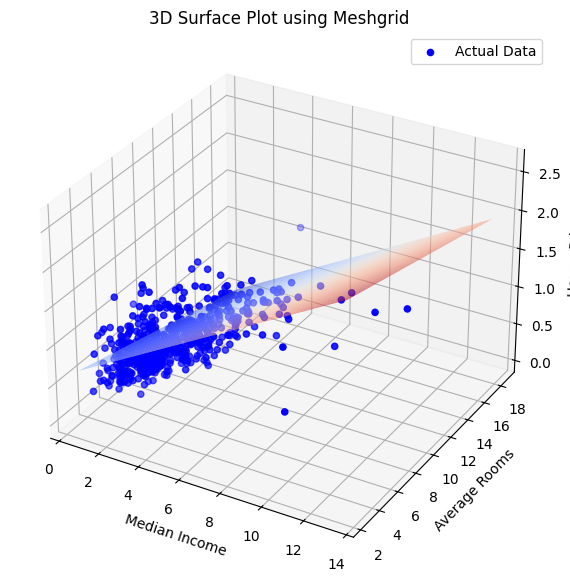

In [7]:
X = df[["MedInc", "AveRooms"]]  
Y = df["MedHouseVal"]  

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model=LinearRegression()
model.fit(X_train,Y_train)

Y_pred = model.predict(X_test)
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of actual test data
ax.scatter(X_test["MedInc"], X_test["AveRooms"], Y_test, color="blue", label="Actual Data")

# Create meshgrid for plotting
x1_range = np.linspace(X_test["MedInc"].min(), X_test["MedInc"].max(), 100)
x2_range = np.linspace(X_test["AveRooms"].min(), X_test["AveRooms"].max(), 100)
x1, x2 = np.meshgrid(x1_range, x2_range)

# Convert meshgrid to 2D input
x_grid = np.c_[x1.ravel(), x2.ravel()]

# Create a DataFrame with ALL 8 FEATURES
feature_names = X_train.columns # Get all 8 feature names
df_grid = pd.DataFrame(np.zeros((x_grid.shape[0], len(feature_names))), columns=feature_names)

# Fill only 'MedInc' and 'AveRooms' columns, keep others at their mean value
df_grid["MedInc"] = x_grid[:, 0]
df_grid["AveRooms"] = x_grid[:, 1]
for col in feature_names:
    if col not in ["MedInc", "AveRooms"]:
        df_grid[col] = X_train[col].mean() # Fill missing features with mean

# Predict using the model
z = model.predict(df_grid).reshape(x1.shape)

# Plot regression surface
ax.plot_surface(x1, x2, z, cmap='coolwarm', alpha=0.6, edgecolor='none')

# Labels
ax.set_xlabel('Median Income')
ax.set_ylabel('Average Rooms')
ax.set_zlabel('House Price')
ax.set_title('3D Surface Plot using Meshgrid')

plt.legend()
plt.show()